In [1]:
import os, sys
import numpy as np
module_path = os.path.abspath(os.path.join('..'))
sys.path.append(os.path.join(module_path, "KAN_variants"))
from ChebyKANLayer import ChebyKAN
from kan import KAN
from fastkan import FastKAN

module_path = os.path.abspath(os.path.join('..'))
sys.path.append(os.path.join(module_path, "code"))
from myKANODE import KANODE

In [2]:
def pred_prey_deriv(X, t, alpha, beta, delta, gamma):
    x=X[0]
    y=X[1]
    dxdt = alpha*x-beta*x*y
    dydt = delta*x*y-gamma*y
    dXdt=[dxdt, dydt]
    return dXdt

# alpha, beta, delta, gamma
params = [1.5, 1, 2, 1]
X0 = [0.1, 1.5]

In [3]:
def vanDerPoll(X, t, epsilon):
    x = X[0]
    y = X[1]
    dxdt = y
    dydt = epsilon*(1-x*x)*y - x
    return [dxdt, dydt]
vdpX0 = [0, 1.5]
vdpParams = [0.2]

In [4]:
model = FastKAN([2, 7, 7, 2], 4)
kanODE = KANODE(model, pred_prey_deriv, X0, params, 20, 7.5, 0.01)

In [5]:
saveDirectory = os.path.join(module_path, "savedModels", "FastKAN")

In [6]:
kanODE.loadModel(saveDirectory, "defaultName 201")

c:\Users\Adam\Documents\GitHub\KAN-project\code\myKANODE.py:159: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model = torch.load(modelPath)
c:\Users\Adam\Documents\Git

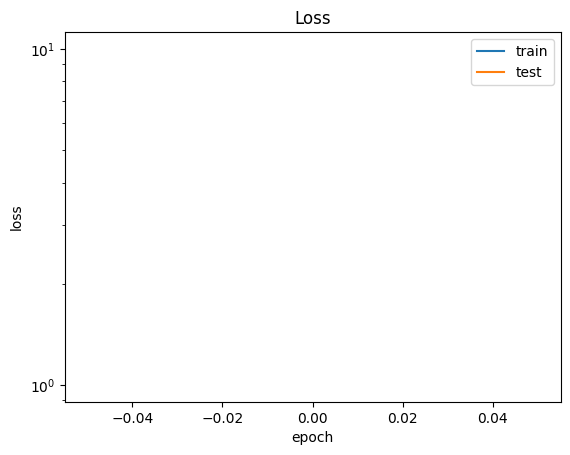

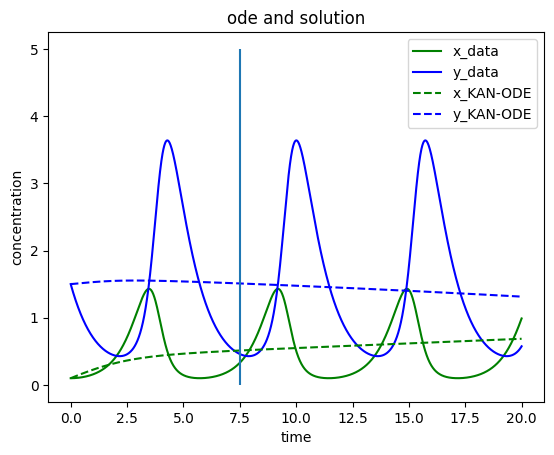

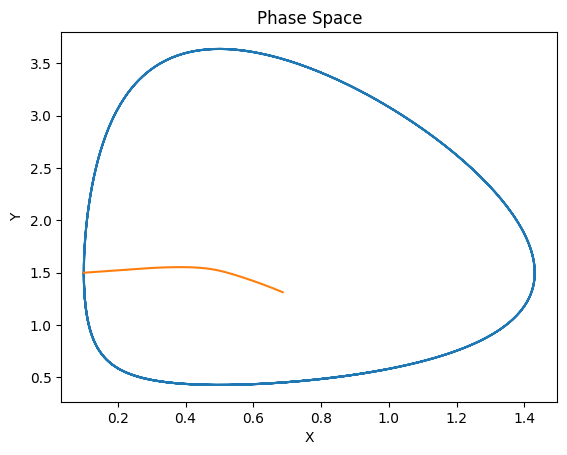

In [7]:
#kanODE.train(500)
_, solution = kanODE.test("rk4")
kanODE.plotLoss("Loss")
kanODE.plotODE("ode and solution", solution[:, 0, :])
kanODE.plotPhaseSpace("Phase Space", solution[:, 0, :])

In [8]:
kanODE.baseSolution

tensor([[0.1000, 1.5000],
        [0.1000, 1.4880],
        [0.1000, 1.4762],
        ...,
        [0.9707, 0.5639],
        [0.9799, 0.5693],
        [0.9890, 0.5748]], requires_grad=True)

In [9]:
points = kanODE.baseSolution.detach().numpy()
x = np.where(np.logical_and(np.round(points[:,0], decimals=1)==0.9, points[:,1]>2))
points[x[0][0], :]

array([0.93621683, 3.2014527 ], dtype=float32)

In [10]:
kanODE.setOdeIC(points[x[0][0], :])

100%|██████████| 100/100 [10:16<00:00,  6.17s/it]


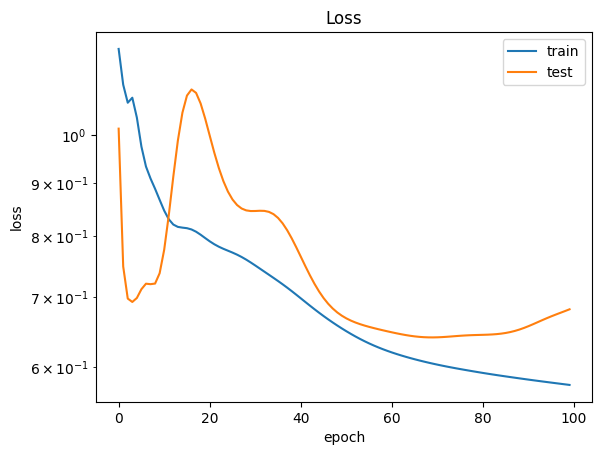

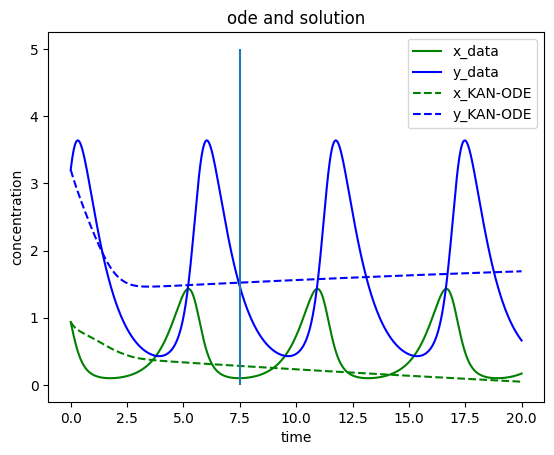

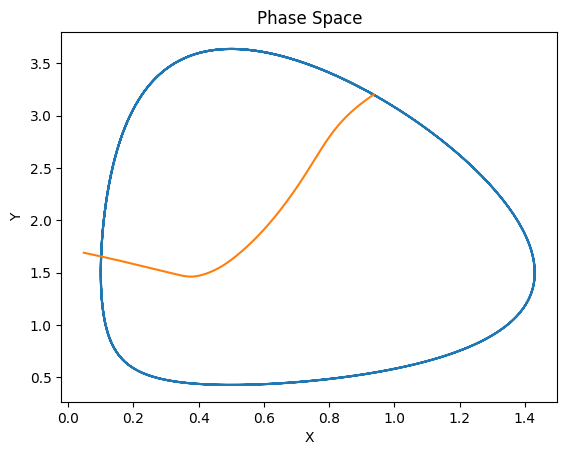

In [11]:
kanODE.train(100, solverMethod="rk4")
_, solution = kanODE.test(solverMethod="rk4")
kanODE.plotLoss("Loss")
kanODE.plotODE("ode and solution", solution[:, 0, :])
kanODE.plotPhaseSpace("Phase Space", solution[:, 0, :])

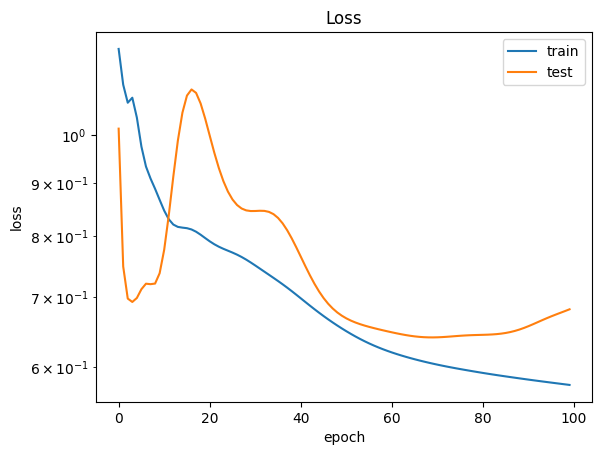

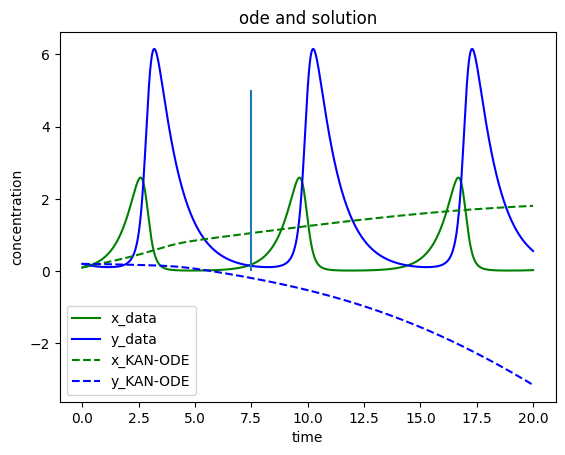

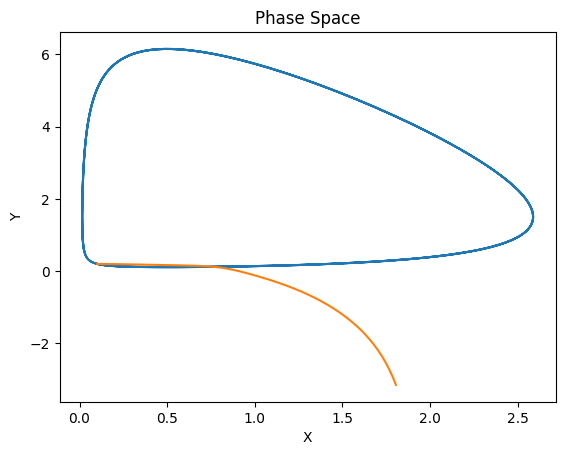

In [12]:
kanODE.setOdeIC([0.1, 0.2])
_, solution = kanODE.test(solverMethod="rk4")
kanODE.plotLoss("Loss")
kanODE.plotODE("ode and solution", solution[:, 0, :])
kanODE.plotPhaseSpace("Phase Space", solution[:, 0, :])